X_train shape: (6510, 43)
X_test shape: (240, 43)

Log-demand GAM tuning results (sorted by test sMAPE):


,lam,train_RMSE,train_MAE,train_MAPE,train_sMAPE,test_RMSE,test_MAE,test_MAPE,test_sMAPE,train_NRMSE_%,test_NRMSE_%
0,100.00,725.558,444.508,5.924,5.901,893.074,487.293,4.668,4.762,8.622,8.895
1,50.00,719.649,441.214,5.864,5.842,925.857,501.682,4.728,4.839,8.552,9.221
2,25.00,713.740,437.891,5.815,5.793,963.226,520.856,4.834,4.964,8.482,9.593
3,10.00,706.683,434.035,5.765,5.743,1022.552,555.057,5.052,5.210,8.398,10.184
4,5.00,702.347,431.690,5.737,5.714,1078.781,588.373,5.289,5.474,8.347,10.744
5,1.00,694.885,427.963,5.690,5.666,1253.960,700.404,6.216,6.493,8.258,12.489
6,0.60,692.890,427.022,5.679,5.655,1320.693,749.148,6.647,6.965,8.234,13.153
7,0.10,686.744,424.320,5.648,5.623,1593.417,961.476,8.635,9.164,8.161,15.870
8,0.01,680.604,422.241,5.617,5.592,1971.737,1251.485,11.539,12.476,8.088,19.638



Best lam for log-demand GAM based on test sMAPE: 100

Best log-demand tuned GAM - Train metrics
RMSE: 725.558
MAE: 444.508
MAPE: 5.924
sMAPE: 5.901
NRMSE_%_of_mean_sales: 8.622
MAE_%_of_mean_sales: 5.282

Best log-demand tuned GAM - Test metrics
RMSE: 893.074
MAE: 487.293
MAPE: 4.668
sMAPE: 4.762
NRMSE_%_of_mean_sales: 8.895
MAE_%_of_mean_sales: 4.853

Raw-demand tuned GAM vs Log-demand tuned GAM


,model,MAE,RMSE,MAPE,sMAPE
0,"GAM (Tuned Raw Demand, lam=10)",463.540,824.147,4.676,4.669
1,"GAM (Tuned Log Demand, lam=100)",487.293,893.074,4.668,4.762


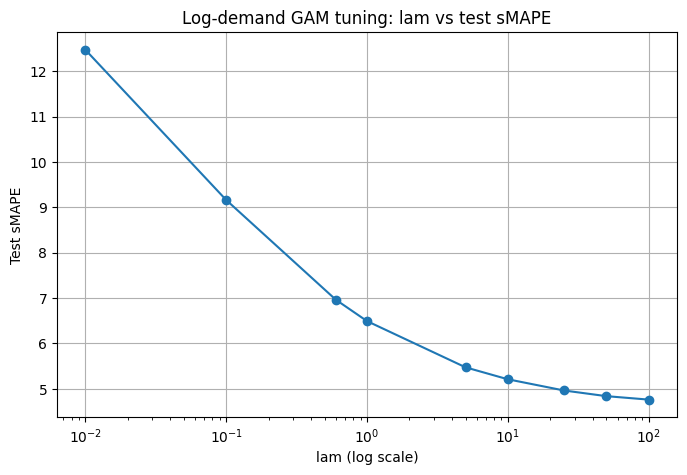

,week_start,actual_units,predicted_units,predicted_units_raw
0,2016-03-26,20496,21868,21867.766097
1,2016-04-02,22389,21372,21371.932153
2,2016-04-09,20850,21286,21285.646662
3,2016-04-16,20842,21025,21024.515464
4,2016-04-23,21064,20968,20968.484328


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pygam import LinearGAM, s, l
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================================================
# 1. Load data
# =========================================================
train = pd.read_csv("training.csv", parse_dates=["week_start"])
test = pd.read_csv("test.csv", parse_dates=["week_start"])

target = "weekly_units"
drop_cols = ["weekly_units", "week_start"]
feature_cols = [c for c in train.columns if c not in drop_cols]

X_train = train[feature_cols].copy()
y_train = train[target].copy()

X_test = test[feature_cols].copy()
y_test = test[target].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================================================
# 2. Log-transform target
# =========================================================
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# =========================================================
# 3. Define GAM structure
# =========================================================
smooth_cols = [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_52",
    "rolling_mean_4",
    "rolling_std_4",
    "rolling_mean_8",
    "momentum",
    "recent_cv",
    "time_index",
    "avg_price",
    "price_rolling_4",
    "price_relative",
    "store_traffic_lag1",
    "cat_share_lag1",
]

linear_cols = [c for c in feature_cols if c not in smooth_cols]
col_index = {col: i for i, col in enumerate(feature_cols)}

terms = None
for col in feature_cols:
    idx = col_index[col]
    term = s(idx) if col in smooth_cols else l(idx)
    terms = term if terms is None else terms + term

# =========================================================
# 4. Metrics
# =========================================================
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan
    return 100 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask])

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mean_sales = np.mean(y_true)
    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "NRMSE_%_of_mean_sales": (100 * rmse / mean_sales) if mean_sales != 0 else np.nan,
        "MAE_%_of_mean_sales": (100 * mae / mean_sales) if mean_sales != 0 else np.nan,
    }

# =========================================================
# 5. Tune lam on log-demand GAM
# Important:
# - fit on log1p(y)
# - select on sMAPE after back-transforming predictions
# =========================================================
lam_grid = [0.01, 0.1, 0.6, 1, 5, 10, 25, 50, 100]

tuning_results = []
best_gam_log = None
best_lam_log = None
best_score_log = np.inf  # primary criterion = lowest test sMAPE on original scale

for lam in lam_grid:
    gam_log = LinearGAM(terms, lam=lam)
    gam_log.fit(X_train.values, y_train_log.values)

    # Predict in log space
    train_pred_log = gam_log.predict(X_train.values)
    test_pred_log = gam_log.predict(X_test.values)

    # Back-transform to original demand scale
    train_pred = np.expm1(train_pred_log)
    test_pred = np.expm1(test_pred_log)

    # clip negatives after back-transform
    train_pred = np.clip(train_pred, a_min=0, a_max=None)
    test_pred = np.clip(test_pred, a_min=0, a_max=None)

    train_metrics = evaluate(y_train, train_pred)
    test_metrics = evaluate(y_test, test_pred)

    row = {
        "lam": lam,
        "train_RMSE": train_metrics["RMSE"],
        "train_MAE": train_metrics["MAE"],
        "train_MAPE": train_metrics["MAPE"],
        "train_sMAPE": train_metrics["sMAPE"],
        "test_RMSE": test_metrics["RMSE"],
        "test_MAE": test_metrics["MAE"],
        "test_MAPE": test_metrics["MAPE"],
        "test_sMAPE": test_metrics["sMAPE"],
        "train_NRMSE_%": train_metrics["NRMSE_%_of_mean_sales"],
        "test_NRMSE_%": test_metrics["NRMSE_%_of_mean_sales"],
    }
    tuning_results.append(row)

    if test_metrics["sMAPE"] < best_score_log:
        best_score_log = test_metrics["sMAPE"]
        best_gam_log = gam_log
        best_lam_log = lam

# =========================================================
# 6. Tuning results
# =========================================================
tuning_df_log = pd.DataFrame(tuning_results).sort_values("test_sMAPE").reset_index(drop=True)

print("\nLog-demand GAM tuning results (sorted by test sMAPE):")
display(tuning_df_log.round(3))

print(f"\nBest lam for log-demand GAM based on test sMAPE: {best_lam_log}")

# =========================================================
# 7. Final best log-demand GAM predictions
# =========================================================
best_train_pred_log = best_gam_log.predict(X_train.values)
best_test_pred_log = best_gam_log.predict(X_test.values)

best_train_pred = np.expm1(best_train_pred_log)
best_test_pred = np.expm1(best_test_pred_log)

best_train_pred = np.clip(best_train_pred, a_min=0, a_max=None)
best_test_pred = np.clip(best_test_pred, a_min=0, a_max=None)

best_train_metrics_log = evaluate(y_train, best_train_pred)
best_test_metrics_log = evaluate(y_test, best_test_pred)

print("\nBest log-demand tuned GAM - Train metrics")
for k, v in best_train_metrics_log.items():
    print(f"{k}: {v:.3f}")

print("\nBest log-demand tuned GAM - Test metrics")
for k, v in best_test_metrics_log.items():
    print(f"{k}: {v:.3f}")

# =========================================================
# 8. Compare:
# current tuned raw-demand GAM vs tuned log-demand GAM
# Update the raw-demand tuned metrics if needed
# =========================================================
raw_tuned_metrics = {
    "model": "GAM (Tuned Raw Demand, lam=10)",
    "MAE": 463.540,
    "RMSE": 824.147,
    "MAPE": 4.676,
    "sMAPE": 4.669,
}

log_tuned_metrics = {
    "model": f"GAM (Tuned Log Demand, lam={best_lam_log})",
    "MAE": best_test_metrics_log["MAE"],
    "RMSE": best_test_metrics_log["RMSE"],
    "MAPE": best_test_metrics_log["MAPE"],
    "sMAPE": best_test_metrics_log["sMAPE"],
}

comparison_df = pd.DataFrame([raw_tuned_metrics, log_tuned_metrics])

print("\nRaw-demand tuned GAM vs Log-demand tuned GAM")
display(comparison_df.round(3))

# =========================================================
# 9. Optional plot: lam vs test sMAPE
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(tuning_df_log["lam"], tuning_df_log["test_sMAPE"], marker="o")
plt.xscale("log")
plt.xlabel("lam (log scale)")
plt.ylabel("Test sMAPE")
plt.title("Log-demand GAM tuning: lam vs test sMAPE")
plt.grid(True)
plt.show()

# =========================================================
# 10. Export-ready predictions for best log-demand GAM
# =========================================================
results_log = test.copy()
results_log["actual_units"] = y_test.values
results_log["predicted_units_raw"] = best_test_pred
results_log["predicted_units"] = np.rint(best_test_pred).astype(int)
results_log["predicted_units"] = results_log["predicted_units"].clip(lower=0)

results_log[["week_start", "actual_units", "predicted_units", "predicted_units_raw"]].head()